Torch: 2.9.0+cu126
Device: cuda
GPU count: 2
GPU 0 Tesla T4
GPU 1 Tesla T4
Classes: ['short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']
Building dataset...


100%|██████████| 23741/23741 [03:42<00:00, 106.64it/s]


Train: 144174
Validation: 23741
Class weights: tensor([1.0425, 1.6228, 2.9682, 3.0327, 3.7077], device='cuda:0')
Training MobileNetV3 from scratch...

Per Class Metrics
short sleeve top
Precision: 0.6349181605611848
Recall: 0.6584754668175572
F1: 0.6464822824491092
AUC: 0.664561898848891

trousers
Precision: 0.6092065247442632
Recall: 0.9283758163050347
F1: 0.7356648026041231
AUC: 0.8855343747301976

shorts
Precision: 0.33237026336259584
Recall: 0.7236873941446891
F1: 0.4555284800487359
AUC: 0.7851601898048595

long sleeve top
Precision: 0.44509688784497947
Recall: 0.3843813387423935
F1: 0.4125170068027211
AUC: 0.7106109326740804

skirt
Precision: 0.5961070559610706
Recall: 0.3392829666102477
F1: 0.4324377328888017
AUC: 0.756626045044468


Epoch 1
Loss: 0.8175095999357228
Macro Precision: 0.5235397784948187
Macro Recall: 0.6068405965239844
Macro F1: 0.5365260609586981
Micro F1: 0.5850235877295912
Macro AUC: 0.7604986882204993
NEW BEST MODEL — SAVING

Per Class Metrics
short sleeve top


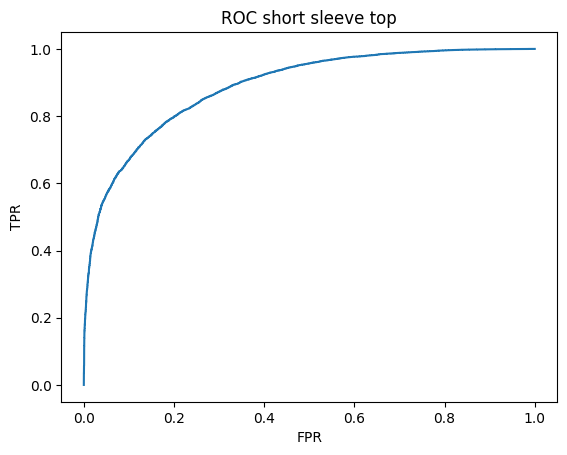

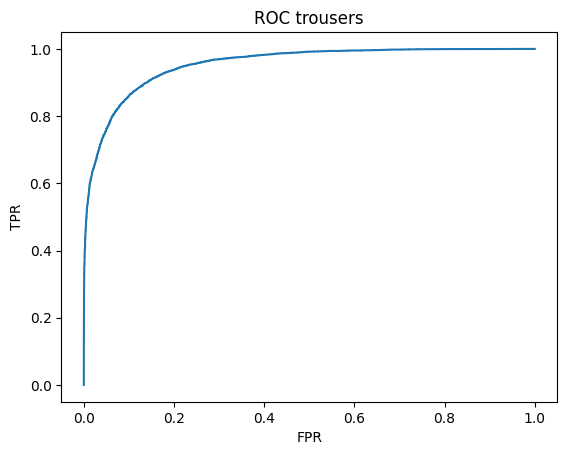

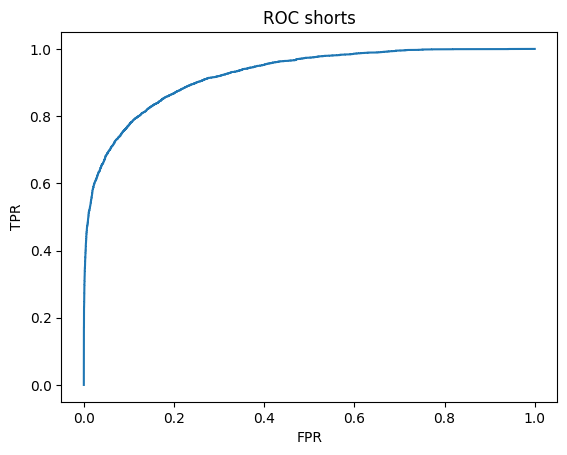

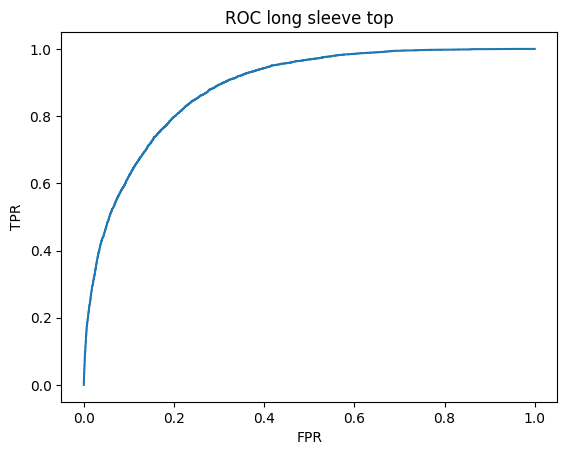

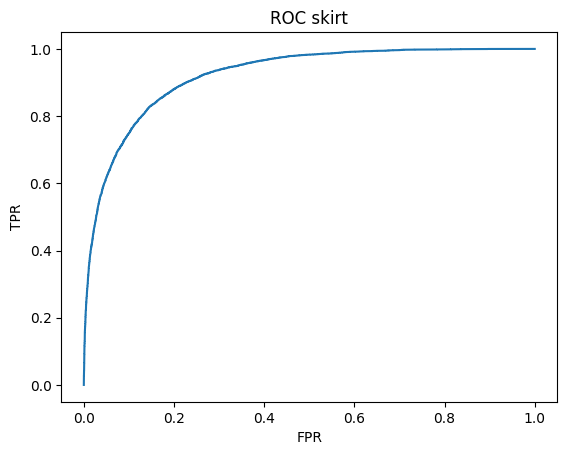

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import os
import json
import numpy as np
import warnings
from PIL import Image
from tqdm import tqdm

warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

from torchvision import transforms
from torchvision.models import mobilenet_v3_large

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt


print("Torch:", torch.__version__)

# ============================================================
# GPU SETUP
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print("GPU", i, torch.cuda.get_device_name(i))


# ============================================================
# DATASET PATHS
# ============================================================
BASE_PATH = "/kaggle/input/datasets/iharshsinha/deepfashion2-top5-processed/processed"

TRAIN_IMAGES = os.path.join(BASE_PATH,"train/images")
TRAIN_ANNOS = os.path.join(BASE_PATH,"train/annos")

VAL_IMAGES = os.path.join(BASE_PATH,"validation/images")
VAL_ANNOS = os.path.join(BASE_PATH,"validation/annos")


# ============================================================
# LABEL MAP
# ============================================================
label_map={
    "short sleeve top":0,
    "trousers":1,
    "shorts":2,
    "long sleeve top":3,
    "skirt":4
}

num_classes=len(label_map)
class_names=list(label_map.keys())

print("Classes:",class_names)


# ============================================================
# BUILD DATASET
# ============================================================
def build_dataset(annos_dir,images_dir):

    dataset=[]

    for file in tqdm(os.listdir(annos_dir)):

        if not file.endswith(".json"):
            continue

        with open(os.path.join(annos_dir,file)) as f:
            data=json.load(f)

        labels=np.zeros(num_classes)

        for k,v in data.items():

            if k.startswith("item"):

                cat=v["category_name"]

                if cat in label_map:
                    labels[label_map[cat]]=1

        img=file.replace(".json",".jpg")

        dataset.append((os.path.join(images_dir,img),labels))

    return dataset


print("Building dataset...")

train_data=build_dataset(TRAIN_ANNOS,TRAIN_IMAGES)
val_data=build_dataset(VAL_ANNOS,VAL_IMAGES)

print("Train:",len(train_data))
print("Validation:",len(val_data))


# ============================================================
# TRANSFORMS
# ============================================================
train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.ToTensor(),
])

val_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])


# ============================================================
# DATASET CLASS
# ============================================================
class FashionDataset(Dataset):

    def __init__(self,data,transform):
        self.data=data
        self.transform=transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self,idx):

        img_path,labels=self.data[idx]

        img=Image.open(img_path).convert("RGB")
        img=self.transform(img)

        labels=torch.tensor(labels,dtype=torch.float32)

        return img,labels


# ============================================================
# DATALOADERS
# ============================================================
batch_size=128

train_dataset=FashionDataset(train_data,train_transform)
val_dataset=FashionDataset(val_data,val_transform)

train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True,num_workers=4,pin_memory=True)
val_loader=DataLoader(val_dataset,batch_size=batch_size,shuffle=False,num_workers=4,pin_memory=True)


# ============================================================
# CLASS IMBALANCE HANDLING
# ============================================================
label_counts=np.zeros(num_classes)

for _,labels in train_data:
    label_counts+=labels

pos_weight=(len(train_data)-label_counts)/label_counts
pos_weight=torch.tensor(pos_weight,dtype=torch.float32).to(device)

print("Class weights:",pos_weight)


# ============================================================
# MODEL (SCRATCH)
# ============================================================
print("Training MobileNetV3 from scratch...")

model = mobilenet_v3_large(weights=None)

model.classifier[3] = nn.Linear(model.classifier[3].in_features,num_classes)

model = model.to(device)

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)


# ============================================================
# LOSS + OPTIMIZER
# ============================================================
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

scaler = GradScaler()


# ============================================================
# TRAIN FUNCTION
# ============================================================
def train_epoch():

    model.train()

    total_loss = 0

    for images,labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with autocast("cuda"):

            outputs = model(images)
            loss = criterion(outputs,labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss/len(train_loader)


# ============================================================
# EVALUATION
# ============================================================
def evaluate():

    model.eval()

    preds=[]
    targets=[]

    with torch.no_grad():

        for images,labels in val_loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            preds.append(probs.cpu().numpy())
            targets.append(labels.numpy())

    preds=np.vstack(preds)
    targets=np.vstack(targets)

    preds_bin=(preds>0.5).astype(int)

    precision_macro = precision_score(targets,preds_bin,average="macro",zero_division=0)
    recall_macro = recall_score(targets,preds_bin,average="macro",zero_division=0)

    f1_macro = f1_score(targets,preds_bin,average="macro",zero_division=0)
    f1_micro = f1_score(targets,preds_bin,average="micro",zero_division=0)

    auc_macro = roc_auc_score(targets,preds,average="macro")

    print("\nPer Class Metrics")

    for i,c in enumerate(class_names):

        p = precision_score(targets[:,i],preds_bin[:,i],zero_division=0)
        r = recall_score(targets[:,i],preds_bin[:,i],zero_division=0)
        f = f1_score(targets[:,i],preds_bin[:,i],zero_division=0)
        auc = roc_auc_score(targets[:,i],preds[:,i])

        print(c)
        print("Precision:",p)
        print("Recall:",r)
        print("F1:",f)
        print("AUC:",auc)
        print()

    return f1_macro,f1_micro,precision_macro,recall_macro,auc_macro,preds,targets


# ============================================================
# TRAIN LOOP
# ============================================================
epochs = 5
best_f1 = 0

for epoch in range(epochs):

    loss = train_epoch()

    f1_macro,f1_micro,precision,recall,auc,preds,targets = evaluate()

    print("\nEpoch",epoch+1)
    print("Loss:",loss)
    print("Macro Precision:",precision)
    print("Macro Recall:",recall)
    print("Macro F1:",f1_macro)
    print("Micro F1:",f1_micro)
    print("Macro AUC:",auc)

    if f1_macro > best_f1:

        best_f1 = f1_macro

        print("NEW BEST MODEL — SAVING")

        state_dict = model.module.state_dict() if hasattr(model,"module") else model.state_dict()

        torch.save(state_dict,"mobilenetv3_multilabel_scratch.pth")
        torch.save(state_dict,"/kaggle/working/mobilenetv3_multilabel_scratch.pth")

        os.makedirs("/kaggle/working/output",exist_ok=True)

        torch.save(state_dict,"/kaggle/working/output/mobilenetv3_multilabel_scratch.pth")


# ============================================================
# ROC CURVES
# ============================================================
for i,c in enumerate(class_names):

    fpr,tpr,_=roc_curve(targets[:,i],preds[:,i])

    plt.figure()
    plt.plot(fpr,tpr)
    plt.title("ROC "+c)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.show()